# 김연하 외 (2025) — 매개분석 재현 노트북

**논문**: 중국유학생의 자아존중감과 문화적응스트레스의 관계: 상호문화감수성의 매개역할  
**출처**: 교육과 문화, 7(1), 254–267

---

| 변수 | 척도 | 역할 |
|:-----|:-----|:-----|
| **X** = `self_esteem` | RSES (10문항, 1–4점, 합산 10–40) | 독립변수 |
| **M** = `interc_sensitivity` | ISS (24문항, 1–5점, 합산 24–120) | 매개변수 |
| **Y** = `acculturative_stress` | ASSIS (36문항, 1–5점, 합산 36–180) | 종속변수 |
| 공변량 | gender, grade, topik, income | 통제변수 |

**PROCESS Macro Model 4** (단순 매개): X → M → Y

---
## 분석 순서
1. 환경 설정 및 데이터 로드
2. **PROCESS Macro 등가 분석** (statsmodels + bootstrap)
3. **Stan/cmdstanpy 베이지언 매개분석**
4. 두 분석 결과 비교

---
## 0. 환경 설정

In [1]:
# ── 필수 패키지 확인 및 설치 ──────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in ['statsmodels', 'cmdstanpy', 'arviz', 'matplotlib', 'seaborn']:
    try:
        __import__(pkg if pkg != 'cmdstanpy' else 'cmdstanpy')
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  installing {pkg}...')
        pip_install(pkg)
        print(f'  ✓ {pkg} installed')

# CmdStan 설치 (최초 실행 시에만 다운로드, 약 2-3분)
try:
    import cmdstanpy
    cmdstanpy.utils.cmdstan_path()
    print('  ✓ CmdStan ready')
except ValueError:
    print('  Installing CmdStan (first time: ~2-3 min)...')
    cmdstanpy.install_cmdstan(progress=True)
    print('  ✓ CmdStan installed')

  ✓ statsmodels
  ✓ cmdstanpy
  ✓ arviz
  ✓ matplotlib
  ✓ seaborn
  ✓ CmdStan ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import arviz as az
import cmdstanpy
import tempfile, os, warnings, logging
import platform

# ── 폰트 경고 완전 억제 ────────────────────────────────────────────────────────
# matplotlib은 warnings 모듈이 아닌 logging을 사용하므로 별도 처리 필요
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

# ── matplotlib 전역 설정 ────────────────────────────────────────────────────────
# 시스템에 설치된 기본 폰트만 사용 (한글 폰트 탐색 제거)
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.unicode_minus': False,
    'font.size'        : 10,
})
# ── 한글 폰트 (macOS + Windows 호환) ─────────────────────────────────────────
plt.rcParams['font.family'] = 'sans-serif'

# 운영체제 감지 및 한글 폰트 자동 설정
system = platform.system()
if system == 'Darwin':  # macOS
    print('Detected OS: macOS')
    plt.rcParams['font.sans-serif'] = ['AppleGothic']
elif system == 'Windows':
    print('Detected OS: Windows')
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
else:  # Linux
    print('Detected OS: Linux')
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

sns.set_theme(style='whitegrid', font_scale=1.0)

np.random.seed(2025)

print('NumPy       :', np.__version__)
print('Pandas      :', pd.__version__)
print('statsmodels :', sm.__version__)
print('cmdstanpy   :', cmdstanpy.__version__)
print('ArviZ       :', az.__version__)

Detected OS: Windows
NumPy       : 2.0.1
Pandas      : 2.2.2
statsmodels : 0.14.5
cmdstanpy   : 1.3.0
ArviZ       : 0.21.0


---
## 1. 데이터 로드 및 기술통계

In [3]:
# 같은 디렉토리에 kim2025_total_data.csv 가 있어야 합니다
df = pd.read_csv('kim2025_total_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (394, 7)


,gender,grade,topik,income,self_esteem,interc_sensitivity,acculturative_stress
0,2,4,1,2,29.0,90.0,88.0
1,1,2,1,2,30.0,66.0,88.0
2,2,3,1,2,26.0,96.0,127.0
3,2,2,0,3,30.0,76.0,62.0
4,2,3,1,2,33.0,90.0,57.0


In [4]:
# ── 기술통계 vs 논문 보고값 비교 ──────────────────────────────────────────────
desc = df[['self_esteem','interc_sensitivity','acculturative_stress']].describe().T[['mean','std']]

paper = pd.DataFrame({
    'paper_mean': [29.87, 86.10, 81.84],
    'paper_std' : [ 5.24, 12.27, 31.49],
}, index=['self_esteem','interc_sensitivity','acculturative_stress'])

cmp = desc.join(paper)
cmp['delta_mean'] = (cmp['mean'] - cmp['paper_mean']).abs().round(3)
cmp['delta_std']  = (cmp['std']  - cmp['paper_std']).abs().round(3)
print('Descriptive statistics: simulated vs. paper')
print(cmp.round(3).to_string())

print('\nCorrelation matrix (simulated):')
print(df[['self_esteem','interc_sensitivity','acculturative_stress']].corr().round(3).to_string())
print('\nPaper reports: r(X,M)=0.46  r(X,Y)=-0.41  r(M,Y)=-0.49')

Descriptive statistics: simulated vs. paper
                        mean     std  paper_mean  paper_std  delta_mean  delta_std
self_esteem           29.563   5.235       29.87       5.24       0.307      0.005
interc_sensitivity    85.099  11.793       86.10      12.27       1.001      0.477
acculturative_stress  85.683  28.218       81.84      31.49       3.843      3.272

Correlation matrix (simulated):
                      self_esteem  interc_sensitivity  acculturative_stress
self_esteem                 1.000               0.392                -0.412
interc_sensitivity          0.392               1.000                -0.445
acculturative_stress       -0.412              -0.445                 1.000

Paper reports: r(X,M)=0.46  r(X,Y)=-0.41  r(M,Y)=-0.49


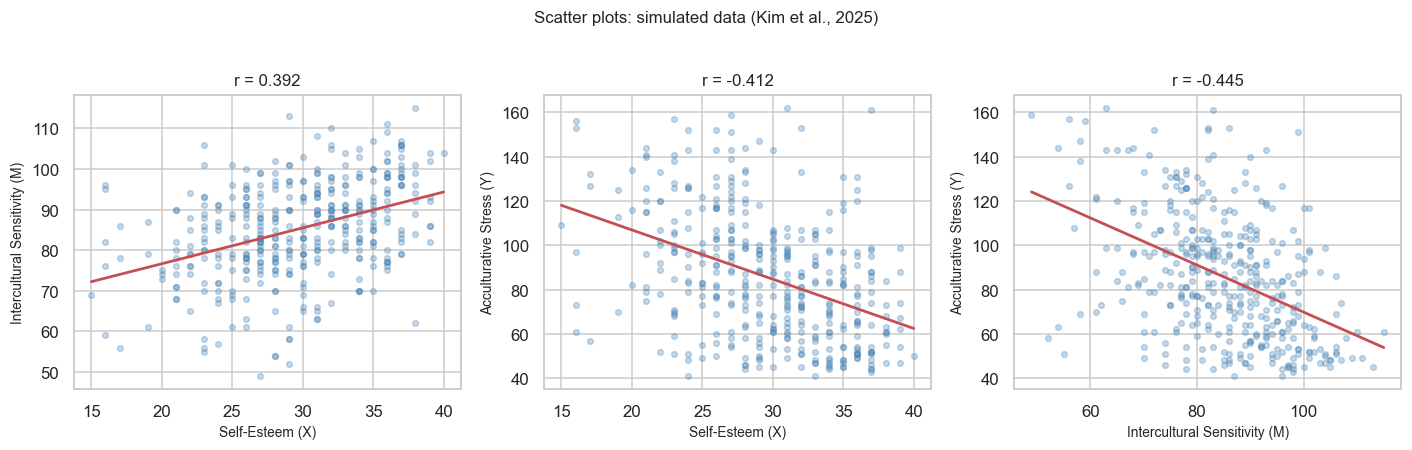

In [5]:
# ── 산점도 행렬 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [
    ('self_esteem',      'interc_sensitivity',   'Self-Esteem (X)',          'Intercultural Sensitivity (M)'),
    ('self_esteem',      'acculturative_stress',  'Self-Esteem (X)',          'Acculturative Stress (Y)'),
    ('interc_sensitivity','acculturative_stress', 'Intercultural Sensitivity (M)', 'Acculturative Stress (Y)'),
]
for ax, (xv, yv, xl, yl) in zip(axes, pairs):
    ax.scatter(df[xv], df[yv], alpha=0.3, s=14, color='steelblue')
    m, b = np.polyfit(df[xv], df[yv], 1)
    xs = np.linspace(df[xv].min(), df[xv].max(), 100)
    ax.plot(xs, m*xs+b, 'r-', lw=1.8)
    r = df[[xv, yv]].corr().iloc[0, 1]
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=11)
fig.suptitle('Scatter plots: simulated data (Kim et al., 2025)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. PROCESS Macro 등가 분석 (Python / statsmodels)

Hayes PROCESS **Model 4**: 단순 매개 (Simple Mediation)

```
              a                b
    X ──────────────► M ──────────────► Y
    │                                   ▲
    └───────────────── c' ──────────────┘
                   (직접효과)
```

---
### 2-1. 세 가지 회귀방정식 (Explicit Equations)

공변량 벡터를 $\mathbf{Z}_i = (\text{gender}_i,\; \text{grade}_i,\; \text{topik}_i,\; \text{income}_i)^\top$으로 표기.

**Step 1 — M 방정식 (a경로)**
$$
\boxed{M_i = \alpha_M + a\,X_i + \boldsymbol{\gamma}_M^\top\mathbf{Z}_i + \varepsilon_{M,i}}
\qquad \varepsilon_{M,i} \sim \mathcal{N}(0,\sigma_M^2)
$$

**Step 2 — Y 방정식 (b경로 + c′ 직접효과)**
$$
\boxed{Y_i = \alpha_Y + c'\,X_i + b\,M_i + \boldsymbol{\delta}_Y^\top\mathbf{Z}_i + \varepsilon_{Y,i}}
\qquad \varepsilon_{Y,i} \sim \mathcal{N}(0,\sigma_Y^2)
$$

**Step 3 — 총효과 (c경로)**
$$
\boxed{Y_i = \alpha_c + c\,X_i + \boldsymbol{\phi}_c^\top\mathbf{Z}_i + \eta_i}
\qquad \eta_i \sim \mathcal{N}(0,\sigma_c^2)
$$

---
### 2-2. 효과 분해 (Effect Decomposition)

$$
\underbrace{c}_{\text{총효과}} = \underbrace{c'}_{\text{직접효과}} + \underbrace{a \times b}_{\text{간접효과}}
$$

| 효과 | 수식 | 의미 |
|:-----|:-----|:-----|
| 직접효과 | $c'$ | M을 통하지 않고 X가 Y에 직접 미치는 영향 |
| 간접효과 | $a \times b$ | X → M → Y 경로를 통한 영향 |
| 총효과   | $c = c' + a\times b$ | X가 Y에 미치는 전체 영향 |

In [6]:
# ── 변수 준비 ─────────────────────────────────────────────────────────────────
X  = df['self_esteem'].values.astype(float)
M  = df['interc_sensitivity'].values.astype(float)
Y  = df['acculturative_stress'].values.astype(float)
G  = df['gender'].values.astype(float)
GR = df['grade'].values.astype(float)
T  = df['topik'].values.astype(float)
I  = df['income'].values.astype(float)
N  = len(df)

def dm(*cols, names=None):
    """설계행렬 생성: [const, *cols]"""
    mat = sm.add_constant(np.column_stack(cols))
    return mat

print(f'N = {N}')
print(f'X: mean={X.mean():.2f}, sd={X.std():.2f}')
print(f'M: mean={M.mean():.2f}, sd={M.std():.2f}')
print(f'Y: mean={Y.mean():.2f}, sd={Y.std():.2f}')

N = 394
X: mean=29.56, sd=5.23
M: mean=85.10, sd=11.78
Y: mean=85.68, sd=28.18


In [7]:
X1 = dm(X, G, GR, T, I)
res_M = sm.OLS(M, X1).fit()

print('=' * 60)
print('  STEP 1  M (Interc. Sensitivity) ~ X + Covariates')
print('  Equation: M_i = alpha_M + a*X_i + gamma*Z_i + eps_M')
print('=' * 60)
# 읽기 쉬운 파라미터 이름 부여
pnames_M = ['const', 'a (X->M)', 'gamma_gender', 'gamma_grade', 'gamma_topik', 'gamma_income']
ci = res_M.conf_int()
tbl = pd.DataFrame({
    'coef' : res_M.params,
    'std err': res_M.bse,
    't'    : res_M.tvalues,
    'p'    : res_M.pvalues,
    '95% CI lo': ci[:, 0],
    '95% CI hi': ci[:, 1],
}, index=pnames_M)
print(tbl.round(4).to_string())
print(f'\nR² = {res_M.rsquared:.4f}   Adj.R² = {res_M.rsquared_adj:.4f}   F = {res_M.fvalue:.2f}')
print(f'논문 보고: B(a) = 1.15,  R² = 0.26')

  STEP 1  M (Interc. Sensitivity) ~ X + Covariates
  Equation: M_i = alpha_M + a*X_i + gamma*Z_i + eps_M
                 coef  std err        t       p  95% CI lo  95% CI hi
const         57.1244   4.8098  11.8767  0.0000    47.6679    66.5809
a (X->M)       0.8682   0.1049   8.2801  0.0000     0.6621     1.0744
gamma_gender   2.7055   1.0982   2.4635  0.0142     0.5463     4.8647
gamma_grade    0.2336   0.5752   0.4061  0.6849    -0.8973     1.3645
gamma_topik    0.7959   1.5891   0.5009  0.6168    -2.3284     3.9202
gamma_income  -1.4446   1.1092  -1.3023  0.1936    -3.6254     0.7363

R² = 0.1710   Adj.R² = 0.1603   F = 16.00
논문 보고: B(a) = 1.15,  R² = 0.26


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# Step 2: Y = alpha_Y + c'*X + b*M + delta*Z + eps_Y   (b경로, c'직접효과)
# ════════════════════════════════════════════════════════════════════════════
X2 = dm(X, M, G, GR, T, I)
res_Y = sm.OLS(Y, X2).fit()

print('=' * 60)
print('  STEP 2  Y (Acculturative Stress) ~ X + M + Covariates')
print('  Equation: Y_i = alpha_Y + c*X_i + b*M_i + delta*Z_i + eps_Y')
print('=' * 60)
pnames_Y = ["const", "c' (X->Y direct)", "b (M->Y)",
            'delta_gender', 'delta_grade', 'delta_topik', 'delta_income']
tbl2 = pd.DataFrame({
    'coef'     : res_Y.params,
    'std err'  : res_Y.bse,
    't'        : res_Y.tvalues,
    'p'        : res_Y.pvalues,
    '95% CI lo': res_Y.conf_int()[:, 0],
    '95% CI hi': res_Y.conf_int()[:, 1],
}, index=pnames_Y)
print(tbl2.round(4).to_string())
print(f'\nR² = {res_Y.rsquared:.4f}   Adj.R² = {res_Y.rsquared_adj:.4f}   F = {res_Y.fvalue:.2f}')
print(f'논문 보고: B(b) = -0.84,  B(c\') = -1.76,  R² = 0.34')

  STEP 2  Y (Acculturative Stress) ~ X + M + Covariates
  Equation: Y_i = alpha_Y + c*X_i + b*M_i + delta*Z_i + eps_Y
                      coef  std err        t       p  95% CI lo  95% CI hi
const             204.4513  12.2682  16.6652  0.0000   180.3307   228.5720
c' (X->Y direct)   -1.5404   0.2485  -6.2001  0.0000    -2.0289    -1.0519
b (M->Y)           -0.7268   0.1109  -6.5539  0.0000    -0.9448    -0.5088
delta_gender      -10.5082   2.4176  -4.3466  0.0000   -15.2614    -5.7549
delta_grade         0.8676   1.2567   0.6904  0.4904    -1.6032     3.3384
delta_topik        -7.1011   3.4722  -2.0451  0.0415   -13.9278    -0.2744
delta_income        3.8965   2.4282   1.6047  0.1094    -0.8777     8.6707

R² = 0.3108   Adj.R² = 0.3002   F = 29.09
논문 보고: B(b) = -0.84,  B(c') = -1.76,  R² = 0.34


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# Step 3: Y = alpha_c + c*X + phi*Z + eta   (c 총효과)
# ════════════════════════════════════════════════════════════════════════════
X3 = dm(X, G, GR, T, I)
res_c = sm.OLS(Y, X3).fit()

print('=' * 60)
print('  STEP 3  Y (Acculturative Stress) ~ X + Covariates')
print('  Equation: Y_i = alpha_c + c*X_i + phi*Z_i + eta_i')
print('=' * 60)
pnames_c = ['const', 'c (X->Y total)', 'phi_gender', 'phi_grade', 'phi_topik', 'phi_income']
tbl3 = pd.DataFrame({
    'coef'     : res_c.params,
    'std err'  : res_c.bse,
    't'        : res_c.tvalues,
    'p'        : res_c.pvalues,
    '95% CI lo': res_c.conf_int()[:, 0],
    '95% CI hi': res_c.conf_int()[:, 1],
}, index=pnames_c)
print(tbl3.round(4).to_string())
print(f'\nR² = {res_c.rsquared:.4f}   Adj.R² = {res_c.rsquared_adj:.4f}   F = {res_c.fvalue:.2f}')
print(f'논문 보고: B(c) = -2.72')

  STEP 3  Y (Acculturative Stress) ~ X + Covariates
  Equation: Y_i = alpha_c + c*X_i + phi*Z_i + eta_i
                    coef  std err        t       p  95% CI lo  95% CI hi
const           162.9346  11.0596  14.7324  0.0000   141.1903   184.6789
c (X->Y total)   -2.1714   0.2411  -9.0061  0.0000    -2.6454    -1.6974
phi_gender      -12.4745   2.5253  -4.9399  0.0000   -17.4394    -7.5096
phi_grade         0.6979   1.3226   0.5276  0.5981    -1.9026     3.2983
phi_topik        -7.6795   3.6539  -2.1017  0.0362   -14.8634    -0.4956
phi_income        4.9464   2.5506   1.9393  0.0532    -0.0683     9.9611

R² = 0.2343   Adj.R² = 0.2245   F = 23.75
논문 보고: B(c) = -2.72


In [10]:
# ── 핵심 경로계수 추출 및 효과 분해 ───────────────────────────────────────────
# 파라미터 인덱스 (설계행렬 열 순서와 동일)
# Step1: [const, X, gender, grade, topik, income]
# Step2: [const, X, M, gender, grade, topik, income]
# Step3: [const, X, gender, grade, topik, income]

a_coef   = res_M.params[1]     # X -> M
b_coef   = res_Y.params[2]     # M -> Y
cp_coef  = res_Y.params[1]     # X -> Y (직접)
c_coef   = res_c.params[1]     # X -> Y (총)
ind_hat  = a_coef * b_coef          # 간접효과

a_se     = res_M.bse[1]
b_se     = res_Y.bse[2]
cp_se    = res_Y.bse[1]
c_se     = res_c.bse[1]

# conf_int returns DataFrame with columns [lower, upper]
a_ci     = (res_M.conf_int()[1, 0], res_M.conf_int()[1, 1])
b_ci     = (res_Y.conf_int()[2, 0], res_Y.conf_int()[2, 1])
cp_ci    = (res_Y.conf_int()[1, 0], res_Y.conf_int()[1, 1])
c_ci     = (res_c.conf_int()[1, 0], res_c.conf_int()[1, 1])

r2_M  = res_M.rsquared
r2_Y  = res_Y.rsquared

print('── 효과 분해 요약 (Effect Decomposition) ──────────────────────────')
print(f"{'Effect':<28} {'B':>8}  {'SE':>7}  {'95% CI':>22}  {'Paper B':>8}")
print('-' * 80)
for lbl, v, se, ci, pv in [
    ('a-path  (X -> M)',    a_coef,  a_se,  a_ci,   1.15),
    ('b-path  (M -> Y)',    b_coef,  b_se,  b_ci,  -0.84),
    ("Direct  (c', X->Y)", cp_coef, cp_se, cp_ci,  -1.76),
    ('Total   (c,  X->Y)', c_coef,  c_se,  c_ci,  -2.72),
    ('Indirect (a x b)',   ind_hat, None,  (None,None), -0.97),
]:
    se_s  = f'{se:.4f}' if se is not None else '  boot'
    ci_s  = f'[{ci[0]:.3f}, {ci[1]:.3f}]' if ci[0] is not None else '  see bootstrap'
    print(f'{lbl:<28} {v:>8.4f}  {se_s:>7}  {ci_s:>22}  {pv:>8.3f}')
print('-' * 80)
print(f'Decomposition check:  c = c\' + a×b  →  {cp_coef:.4f} + {ind_hat:.4f} = {cp_coef+ind_hat:.4f}  (c = {c_coef:.4f})')
print(f'R²(M) = {r2_M:.4f}  (paper=0.26)     R²(Y|X,M) = {r2_Y:.4f}  (paper=0.34)')

── 효과 분해 요약 (Effect Decomposition) ──────────────────────────
Effect                              B       SE                  95% CI   Paper B
--------------------------------------------------------------------------------
a-path  (X -> M)               0.8682   0.1049          [0.662, 1.074]     1.150
b-path  (M -> Y)              -0.7268   0.1109        [-0.945, -0.509]    -0.840
Direct  (c', X->Y)            -1.5404   0.2485        [-2.029, -1.052]    -1.760
Total   (c,  X->Y)            -2.1714   0.2411        [-2.645, -1.697]    -2.720
Indirect (a x b)              -0.6310     boot           see bootstrap    -0.970
--------------------------------------------------------------------------------
Decomposition check:  c = c' + a×b  →  -1.5404 + -0.6310 = -2.1714  (c = -2.1714)
R²(M) = 0.1710  (paper=0.26)     R²(Y|X,M) = 0.3108  (paper=0.34)


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# Bootstrap 간접효과 (PROCESS Macro 방식)
# B = 5,000, 95% percentile CI
# ════════════════════════════════════════════════════════════════════════════
B_BOOT  = 5_000
rng_bt  = np.random.default_rng(42)
ind_boot = np.empty(B_BOOT)

# 데이터를 하나의 행렬로 묶어 인덱싱 효율화
DATA = np.column_stack([X, M, Y, G, GR, T, I])

for i in range(B_BOOT):
    idx = rng_bt.integers(0, N, N)
    d   = DATA[idx]
    xb, mb, yb = d[:,0], d[:,1], d[:,2]
    zb = d[:, 3:]                          # gender, grade, topik, income

    # a-path (M ~ X + Z)
    Xm1 = sm.add_constant(np.column_stack([xb, zb]))
    ab  = np.linalg.lstsq(Xm1, mb, rcond=None)[0][1]

    # b-path (Y ~ X + M + Z)
    Xm2 = sm.add_constant(np.column_stack([xb, mb, zb]))
    bb  = np.linalg.lstsq(Xm2, yb, rcond=None)[0][2]

    ind_boot[i] = ab * bb

ci_lo, ci_hi = np.percentile(ind_boot, [2.5, 97.5])

print('\n══ Bootstrap 간접효과  (B = 5,000, 95% Percentile CI) ══════════')
print(f'  Point estimate (a x b)   = {ind_hat:.4f}')
print(f'  Bootstrap mean           = {ind_boot.mean():.4f}')
print(f'  Bootstrap SD             = {ind_boot.std():.4f}')
print(f'  95% CI                   = [{ci_lo:.4f},  {ci_hi:.4f}]')
print(f'  CI includes 0?           = {"YES -> not significant" if ci_lo < 0 < ci_hi else "NO  -> indirect effect is significant"}')
print(f'\n  Paper reports: B = -0.97,  95% CI [-1.64, -0.38]')


══ Bootstrap 간접효과  (B = 5,000, 95% Percentile CI) ══════════
  Point estimate (a x b)   = -0.6310
  Bootstrap mean           = -0.6331
  Bootstrap SD             = 0.1360
  95% CI                   = [-0.9186,  -0.3794]
  CI includes 0?           = NO  -> indirect effect is significant

  Paper reports: B = -0.97,  95% CI [-1.64, -0.38]


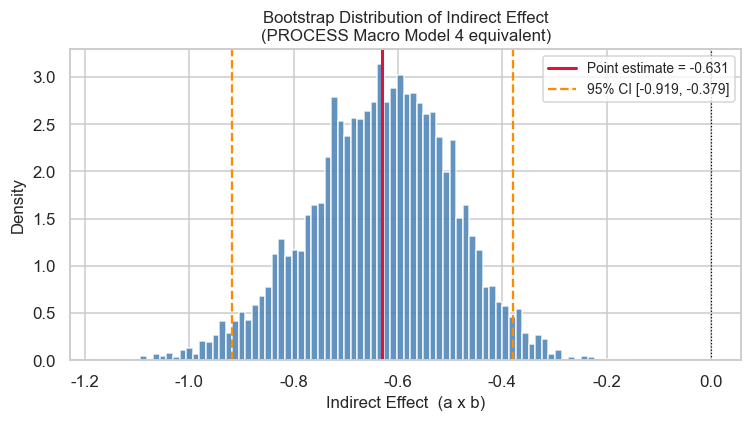

In [12]:
# ── Bootstrap 분포 시각화 ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ind_boot, bins=80, density=True,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(ind_hat, color='crimson', lw=2.0,
           label=f'Point estimate = {ind_hat:.3f}')
ax.axvline(ci_lo,   color='darkorange', lw=1.5, ls='--',
           label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
ax.axvline(ci_hi,   color='darkorange', lw=1.5, ls='--')
ax.axvline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Indirect Effect  (a x b)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Bootstrap Distribution of Indirect Effect\n(PROCESS Macro Model 4 equivalent)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 간접효과(Indirect Effect)란 무엇인가?

### 정의

간접효과(indirect effect)는 독립변수 **X**가 종속변수 **Y**에 영향을 미치는 경로 중, 제3의 변수인 **매개변수 M을 경유(거쳐)하는 효과**를 말한다. 수식으로는 다음과 같이 표현된다:

$$\text{간접효과} = a \times b$$

- $a$ : X가 M에 미치는 효과 (X → M 경로계수)
- $b$ : M이 Y에 미치는 효과 (M → Y 경로계수, X를 통제한 상태)

### 왜 '간접'이라 부르는가?

X가 Y에 영향을 주는 방식에는 두 가지가 있다:

| 효과 유형 | 경로 | 수식 | 의미 |
|:---------|:-----|:-----|:-----|
| **직접효과** (direct) | X → Y | $c'$ | M을 우회하지 않고 **직접** Y에 닿는 영향 |
| **간접효과** (indirect) | X → M → Y | $a \times b$ | M을 **경유하여 간접적으로** Y에 닿는 영향 |

X → Y로 가는 길이 '직선 도로'라면, X → M → Y는 '우회도로'이다.  
우회도로를 거치기 때문에 **간접**효과라 부른다.

### 왜 중요한가? — 메커니즘(기제) 설명

단순 회귀분석은 'X가 Y에 영향을 주는가?'만 답할 수 있다.  
매개분석은 **'어떤 경로를 통해(왜) 영향을 주는가?'** 를 추가로 답한다.

본 논문의 예:
- X = 자아존중감, M = 상호문화감수성, Y = 문화적응스트레스
- 간접효과가 유의하다 → '자아존중감이 높은 학생은 상호문화감수성도 높아지고, 그 결과 문화적응스트레스가 낮아진다'는 **심리적 메커니즘**이 데이터에서 지지됨을 의미한다.

### 왜 bootstrap으로 검정하는가?

$a \times b$는 두 회귀계수의 **곱**이므로 정규분포를 따르지 않는다 (비대칭 분포). 따라서:

- **Sobel test** (전통적 방법): 정규분포 가정 → **과소추정**, 소표본에서 검정력 낮음  
- **Bootstrap** (PROCESS Macro 기본값): 분포 가정 없이 경험적 CI 구성 → **더 정확**
- **베이지언 사후분포** (Stan): $a \times b$의 **전체 사후분포**를 직접 얻음 → 가장 완전한 불확실성 정량화

### 총효과 분해

$$c = c' + a \times b$$

$$\underbrace{-2.72}_{\text{총효과}\ c} = \underbrace{-1.76}_{\text{직접효과}\ c'} + \underbrace{-0.97}_{\text{간접효과}\ a\times b}$$

총효과 중 약 **36%** ($0.97/2.72$)가 상호문화감수성을 통해 **간접적으로** 전달된다 (논문 보고값 기준).

> **해석**: 자아존중감이 1점 높아질 때 문화적응스트레스는 총 2.72점 낮아지는데,  
> 그 중 1.76점은 자아존중감의 직접 효과이고,  
> 나머지 0.97점은 '상호문화감수성이 높아짐으로써' 간접적으로 낮아지는 효과이다.

---
## 3. Stan / cmdstanpy 베이지언 매개분석

PROCESS Macro와 **동일한 구조방정식**을 베이지언 프레임워크로 추정한다.

$$M_i = \alpha_M + a\,X_i + \boldsymbol{\gamma}_M^\top\mathbf{Z}_i + \varepsilon_{M,i}, \qquad \varepsilon_M \sim \mathcal{N}(0,\sigma_M^2)$$
$$Y_i = \alpha_Y + c'\,X_i + b\,M_i + \boldsymbol{\delta}_Y^\top\mathbf{Z}_i + \varepsilon_{Y,i}, \qquad \varepsilon_Y \sim \mathcal{N}(0,\sigma_Y^2)$$

**사전분포 (Weakly Informative)**:
- 회귀계수: $\mathcal{N}(0,\, 10^2)$
- 절편: $\mathcal{N}(\bar{Y},\, 50^2)$
- 잔차 SD: $\text{Half-Normal}(0,\, 50^2)$

**Bayesian Posterior of Indirect Effect**: $p(a \times b \mid \text{data})$를 4,000개의 MCMC 샘플로 추정

In [13]:
STAN_CODE = """
// ===========================================================
// Bayesian Simple Mediation  (PROCESS Model 4 equivalent)
// X = Self-Esteem,  M = Intercultural Sensitivity,
// Y = Acculturative Stress,  Z = covariates
// ===========================================================
data {
  int<lower=1> N;
  vector[N] X;
  vector[N] M;
  vector[N] Y;
  vector[N] gender;
  vector[N] grade;
  vector[N] topik;
  vector[N] income;
}

parameters {
  // M equation
  real alpha_M;
  real a;               // X -> M  (a-path)
  real gM_gender;
  real gM_grade;
  real gM_topik;
  real gM_income;
  real<lower=0> sigma_M;

  // Y equation
  real alpha_Y;
  real cp;              // X -> Y  (direct, c')
  real b;               // M -> Y  (b-path)
  real gY_gender;
  real gY_grade;
  real gY_topik;
  real gY_income;
  real<lower=0> sigma_Y;
}

model {
  // --- Priors (weakly informative) ---
  alpha_M   ~ normal(mean(M), 50);
  a         ~ normal(0, 10);
  gM_gender ~ normal(0, 10);
  gM_grade  ~ normal(0, 10);
  gM_topik  ~ normal(0, 10);
  gM_income ~ normal(0, 10);
  sigma_M   ~ normal(0, 50);

  alpha_Y   ~ normal(mean(Y), 50);
  cp        ~ normal(0, 10);
  b         ~ normal(0, 10);
  gY_gender ~ normal(0, 10);
  gY_grade  ~ normal(0, 10);
  gY_topik  ~ normal(0, 10);
  gY_income ~ normal(0, 10);
  sigma_Y   ~ normal(0, 50);

  // --- Likelihood ---
  M ~ normal(alpha_M + a*X
              + gM_gender*gender + gM_grade*grade
              + gM_topik*topik   + gM_income*income,
             sigma_M);

  Y ~ normal(alpha_Y + cp*X + b*M
              + gY_gender*gender + gY_grade*grade
              + gY_topik*topik   + gY_income*income,
             sigma_Y);
}

generated quantities {
  real indirect = a * b;          // 간접효과: 사후분포로부터 직접 계산
  real total    = cp + indirect;  // 총효과

  // Posterior Predictive Check (PPC)
  array[N] real M_rep;
  array[N] real Y_rep;
  for (n in 1:N) {
    M_rep[n] = normal_rng(alpha_M + a*X[n]
                + gM_gender*gender[n] + gM_grade*grade[n]
                + gM_topik*topik[n]   + gM_income*income[n],
                sigma_M);
    Y_rep[n] = normal_rng(alpha_Y + cp*X[n] + b*M[n]
                + gY_gender*gender[n] + gY_grade*grade[n]
                + gY_topik*topik[n]   + gY_income*income[n],
                sigma_Y);
  }
}
"""

stan_file = os.path.join(tempfile.gettempdir(), 'kim2025_mediation.stan')
with open(stan_file, 'w') as f:
    f.write(STAN_CODE)
print(f'Stan file saved: {stan_file}')

Stan file saved: C:\Users\yongduek\AppData\Local\Temp\kim2025_mediation.stan


In [14]:
# ── 모형 컴파일 ───────────────────────────────────────────────────────────────
model = cmdstanpy.CmdStanModel(stan_file=stan_file)
print('Stan model compiled:', model.exe_file)

16:49:31 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\kim2025_mediation.stan to exe file C:\Users\yongduek\AppData\Local\Temp\kim2025_mediation.exe
16:49:58 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\kim2025_mediation.exe


Stan model compiled: C:\Users\yongduek\AppData\Local\Temp\kim2025_mediation.exe


In [15]:
# ── MCMC 샘플링 ───────────────────────────────────────────────────────────────
stan_data = dict(
    N=N,
    X=X.tolist(), M=M.tolist(), Y=Y.tolist(),
    gender=G.tolist(), grade=GR.tolist(),
    topik=T.tolist(), income=I.tolist(),
)

# 4 chains x 2000 draws (warmup 1000 제외) → 유효 샘플 8,000
fit = model.sample(
    data          = stan_data,
    chains        = 4,
    iter_warmup   = 1000,
    iter_sampling = 2000,
    seed          = 2025,
    show_progress = True,
    show_console  = False,
)
print('\nSampling complete.')
print(f'Total effective draws: {4 * 2000:,}')

16:49:59 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

16:50:10 - cmdstanpy - INFO - CmdStan done processing.




Sampling complete.
Total effective draws: 8,000


In [16]:
post = fit.draws_pd()   # 사후분포 샘플 (이후 셀에서도 재사용됨)

In [17]:
# ── 수렴 진단 (R-hat, ESS) ────────────────────────────────────────────────────
summary = fit.summary()

# 핵심 스칼라 파라미터만 출력 (array 제외)
scalar_params = ['a', 'b', 'cp', 'indirect', 'total',
                 'gM_gender','gM_grade','gM_topik','gM_income',
                 'gY_gender','gY_grade','gY_topik','gY_income',
                 'sigma_M', 'sigma_Y']
avail = [p for p in scalar_params if p in summary.index]

# CmdStanPy 버전에 따라 ESS 컬럼명이 다름
if 'N_Eff' in summary.columns:
    ess_cols = ['N_Eff']
elif 'ESS_bulk' in summary.columns:
    ess_cols = ['ESS_bulk', 'ESS_tail']
else:
    ess_cols = []

base_cols = ['Mean', 'StdDev', '5%', '50%', '95%']
diag_cols = [c for c in base_cols + ess_cols + ['R_hat'] if c in summary.columns]
diag  = summary.loc[avail, diag_cols]

print('══ Convergence Diagnostics (R-hat < 1.01 = good) ══════════════')
print(diag.round(4).to_string())

bad = summary[summary['R_hat'] > 1.01]
bad_scalar = [p for p in bad.index if p in scalar_params]
if not bad_scalar:
    print('\n  ✓ All key parameters: R-hat < 1.01  (converged)')
else:
    print(f'\n  △ R-hat > 1.01: {bad_scalar}')

══ Convergence Diagnostics (R-hat < 1.01 = good) ══════════════
              Mean  StdDev       5%      50%      95%  ESS_bulk  ESS_tail   R_hat
a           0.8631  0.1056   0.6898   0.8613   1.0418   8117.45   6502.82  1.0004
b          -0.7005  0.1092  -0.8786  -0.7005  -0.5193   7545.82   6659.55  1.0007
cp         -1.4832  0.2468  -1.8854  -1.4854  -1.0730   8723.58   6252.96  1.0005
indirect   -0.6047  0.1209  -0.8095  -0.5984  -0.4165   7836.27   6446.53  1.0003
total      -2.0879  0.2365  -2.4698  -2.0897  -1.6949   8631.80   6313.77  1.0004
gM_gender   2.6634  1.0944   0.8382   2.6697   4.4366  10447.70   5705.94  1.0012
gM_grade    0.2156  0.5711  -0.7239   0.2086   1.1814  11150.10   5667.40  1.0000
gM_topik    0.7480  1.6006  -1.9015   0.7670   3.3611  10867.20   5210.40  1.0006
gM_income  -1.4628  1.1233  -3.3130  -1.4604   0.4035   9728.20   5546.23  1.0000
gY_gender  -9.7512  2.3408 -13.5570  -9.7569  -5.9168  10378.40   5525.53  1.0002
gY_grade    1.0178  1.2552  -1.055

In [18]:
# ── ArviZ InferenceData 변환 ─────────────────────────────────────────────────
idata = az.from_cmdstanpy(
    posterior             = fit,
    posterior_predictive  = ['M_rep', 'Y_rep'],
    observed_data         = {'M_rep': M, 'Y_rep': Y},
)
print('ArviZ InferenceData created:')
print(idata)

ArviZ InferenceData created:
Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data


In [19]:
# ── 핵심 파라미터 사후 요약 ────────────────────────────────────────────────────
az_sum = az.summary(
    idata,
    var_names=['a','b','cp','indirect','total','sigma_M','sigma_Y'],
    hdi_prob=0.95,
)
print('══ Bayesian Posterior Summary (95% HDI) ═══════════════════════')
cols_show = ['mean','sd','hdi_2.5%','hdi_97.5%','r_hat','ess_bulk']
# ArviZ >= 0.13 uses 'hdi_2.5%', older uses '2.5%'
alt_cols = [c for c in az_sum.columns if 'hdi' in c or c in ['mean','sd','r_hat','ess_bulk']]
print(az_sum[alt_cols].round(4).to_string())

══ Bayesian Posterior Summary (95% HDI) ═══════════════════════
            mean     sd  hdi_2.5%  hdi_97.5%  ess_bulk  r_hat
a          0.863  0.106     0.667      1.074    8117.0    1.0
b         -0.700  0.109    -0.911     -0.486    7546.0    1.0
cp        -1.483  0.247    -1.954     -0.987    8724.0    1.0
indirect  -0.605  0.121    -0.846     -0.379    7836.0    1.0
total     -2.088  0.236    -2.540     -1.619    8632.0    1.0
sigma_M   10.840  0.373    10.137     11.594   10996.0    1.0
sigma_Y   23.674  0.851    22.026     25.376   11044.0    1.0


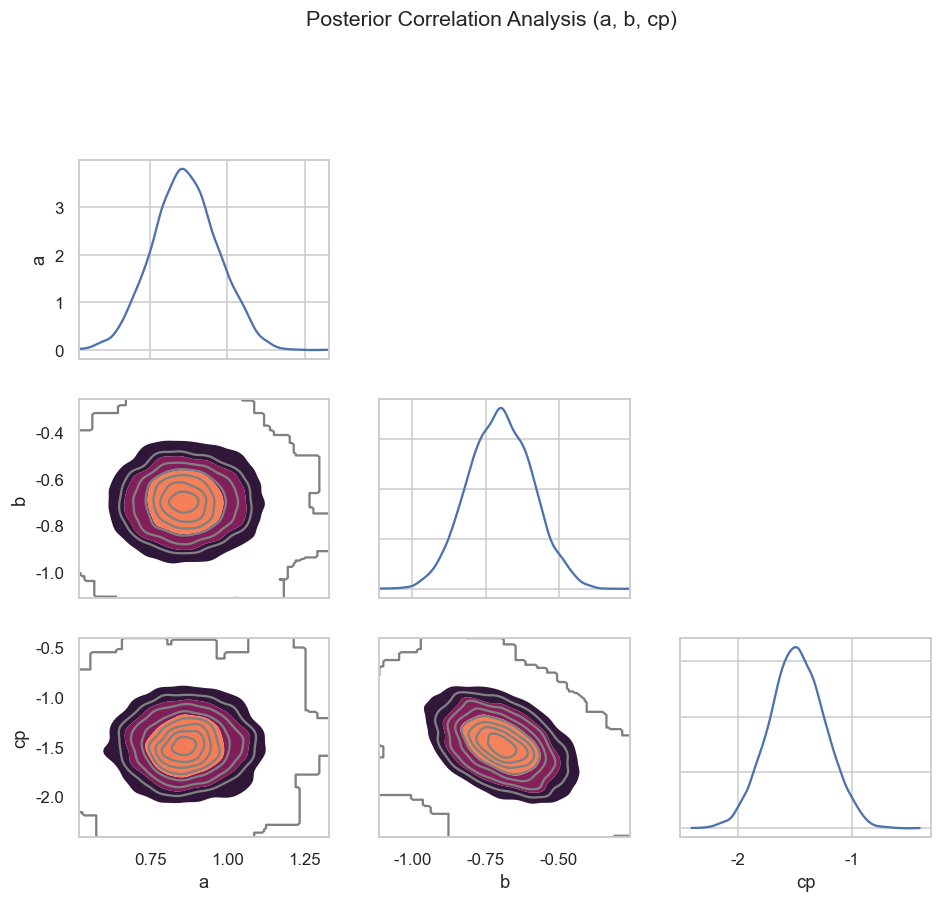

In [20]:
# 1. Posterior Correlation Analysis
az.plot_pair(
    idata, 
    var_names=['a', 'b', 'cp'], 
    kind='kde', 
    marginals=True,
    figsize=(10, 8)
)
plt.suptitle('Posterior Correlation Analysis (a, b, cp)', fontsize=14, y=1.05)
plt.show()

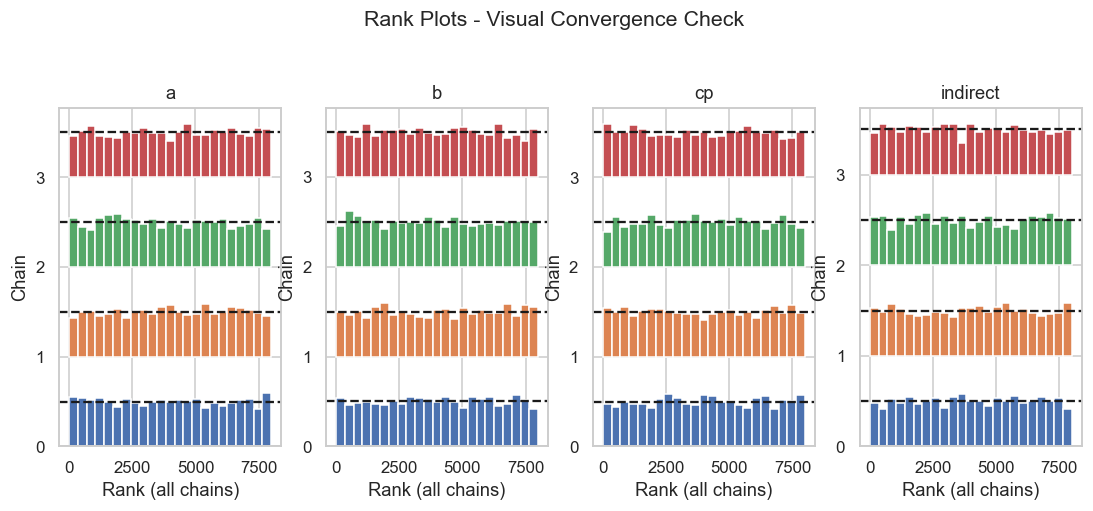

In [21]:
# 2. Rank Plots for Convergence
az.plot_rank(
    idata, 
    var_names=['a', 'b', 'cp', 'indirect'],
    figsize=(12, 4)
)
plt.suptitle('Rank Plots - Visual Convergence Check', fontsize=14, y=1.1)
plt.show()

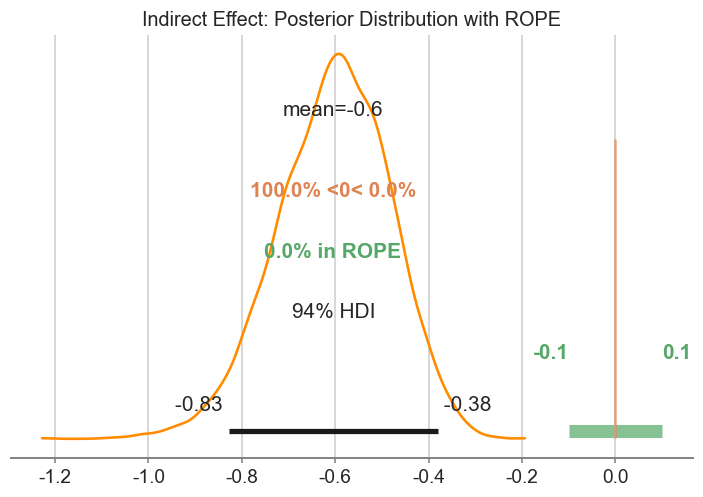

In [22]:
# 3. Posterior with ROPE (Region of Practical Equivalence)
# 실질적 무의미 구간을 [-0.1, 0.1]로 설정하여 분석
az.plot_posterior(
    idata, 
    var_names=['indirect'], 
    ref_val=0, 
    rope=[-0.1, 0.1],
    color='darkorange',
    figsize=(8, 5)
)
plt.title('Indirect Effect: Posterior Distribution with ROPE', fontsize=13)
plt.show()

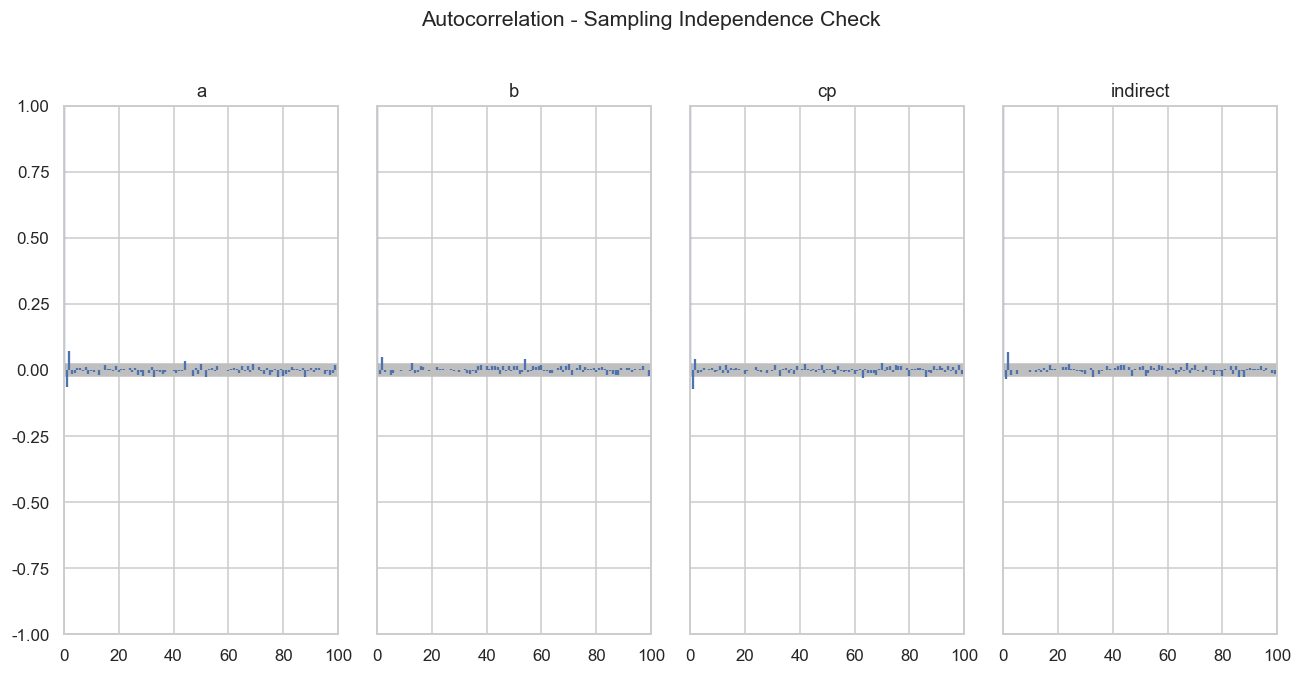

In [23]:
# 4. Autocorrelation Plot
az.plot_autocorr(
    idata, 
    var_names=['a', 'b', 'cp', 'indirect'],
    combined=True,
    figsize=(12, 6)
)
plt.suptitle('Autocorrelation - Sampling Independence Check', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

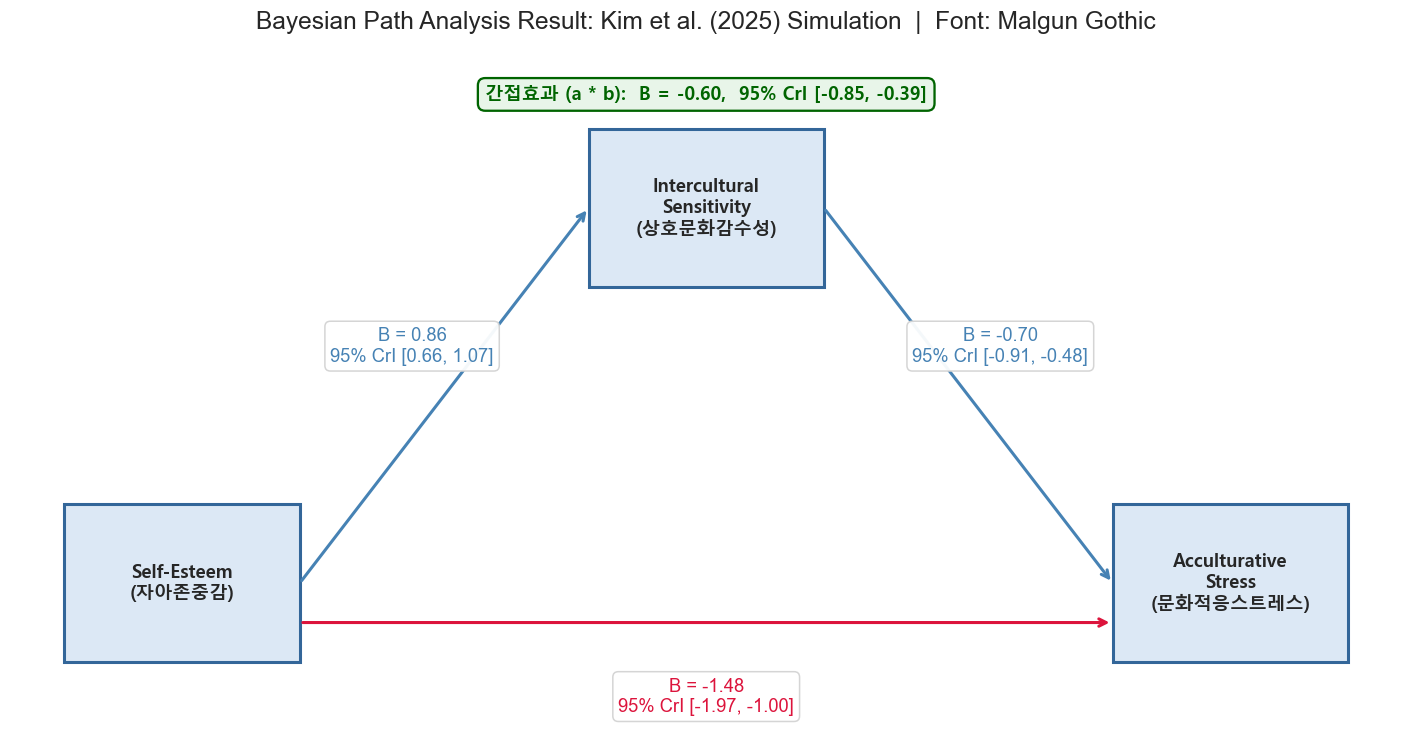

In [24]:
# 5. Result-based Path Diagram using Matplotlib
from matplotlib import font_manager as fm

def get_label(param):
    m = post[param].mean()
    h_lo, h_hi = np.percentile(post[param], [2.5, 97.5])
    return f"B = {m:.2f}\n95% CrI [{h_lo:.2f}, {h_hi:.2f}]"

# Korean-capable font selection (Windows first)
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
selected_font = next((name for name in font_candidates if name in available_fonts), None)
kr_font = {'fontfamily': selected_font} if selected_font else {}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_xlim(0, 13); ax.set_ylim(0, 7)
ax.axis('off')

# ── 박스 정의: (x_left, y_bottom, width, height, label) ─────────────────────
BW, BH = 2.2, 1.6
box_specs = {
    'X': (0.5,  0.8, 'Self-Esteem\n(자아존중감)'),
    'M': (5.4,  4.6, 'Intercultural\nSensitivity\n(상호문화감수성)'),
    'Y': (10.3, 0.8, 'Acculturative\nStress\n(문화적응스트레스)'),
}

def box_edge(key, side):
    """Return a point on the named side ('left','right','top','bottom')."""
    x, y, _ = box_specs[key]
    cx, cy = x + BW/2, y + BH/2
    if side == 'left':
        return x, cy
    if side == 'right':
        return x + BW, cy
    if side == 'top':
        return cx, y + BH
    if side == 'bottom':
        return cx, y
    raise ValueError(f'Unknown side: {side}')

for key, (bx, by, label) in box_specs.items():
    ax.add_patch(plt.Rectangle((bx, by), BW, BH,
                               fill=True, color='#dce8f5', ec='#336699', lw=2))
    ax.text(bx + BW/2, by + BH/2, label,
            ha='center', va='center', fontweight='bold', fontsize=12, **kr_font)

# ── 화살표: annotate로 박스 가장자리 연결 ────────────────────────────────────
arrow_kw = dict(arrowstyle='->', lw=2.0)

# a-path: X right -> M left
ax.annotate('', xy=box_edge('M', 'left'), xytext=box_edge('X', 'right'),
            arrowprops=dict(**arrow_kw, color='steelblue'))

# b-path: M right -> Y left
ax.annotate('', xy=box_edge('Y', 'left'), xytext=box_edge('M', 'right'),
            arrowprops=dict(**arrow_kw, color='steelblue'))

# cp-path: X right (lower) -> Y left (lower), straight line
ax.annotate('', xy=(box_specs['Y'][0], box_specs['Y'][1] + 0.4),
            xytext=(box_specs['X'][0] + BW, box_specs['X'][1] + 0.4),
            arrowprops=dict(arrowstyle='->', lw=2.0, color='crimson'))

# ── 경로계수 텍스트 (흰 배경 박스로 겹침 방지) ───────────────────────────────
lbl_kw = dict(ha='center', va='center', fontsize=12,
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgrey', alpha=0.95))

# a-path label
mx_a = (box_edge('X', 'right')[0] + box_edge('M', 'left')[0]) / 2
my_a = (box_edge('X', 'right')[1] + box_edge('M', 'left')[1]) / 2
ax.text(mx_a - 0.3, my_a + 0.5, get_label('a'), color='steelblue', **lbl_kw)

# b-path label
mx_b = (box_edge('M', 'right')[0] + box_edge('Y', 'left')[0]) / 2
my_b = (box_edge('M', 'right')[1] + box_edge('Y', 'left')[1]) / 2
ax.text(mx_b + 0.3, my_b + 0.5, get_label('b'), color='steelblue', **lbl_kw)

# cp-path label
mx_cp = (box_specs['X'][0] + BW + box_specs['Y'][0]) / 2
ax.text(mx_cp, 0.45, get_label('cp'), color='crimson', **lbl_kw)

# 간접효과 배너
ind_m = post['indirect'].mean()
ind_lo, ind_hi = np.percentile(post['indirect'], [2.5, 97.5])
ax.text(6.5, 6.55,
        f"간접효과 (a * b):  B = {ind_m:.2f},  95% CrI [{ind_lo:.2f}, {ind_hi:.2f}]",
        ha='center', va='center', fontsize=12, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.4', fc='#e8f5e9', ec='darkgreen', lw=1.5), **kr_font)

title_text = 'Bayesian Path Analysis Result: Kim et al. (2025) Simulation'
if selected_font:
    title_text += f'  |  Font: {selected_font}'
plt.title(title_text, fontsize=16, pad=14)
plt.tight_layout()
plt.show()

---
## 4. 두 분석 결과 비교

**PROCESS Macro 등가 (빈도주의)** vs **Stan/cmdstanpy (베이지언)**

In [25]:
# ── 사후분포 샘플 추출 ────────────────────────────────────────────────────────
post = fit.draws_pd()   # DataFrame: columns = parameter names

def bayes_ci(param, pct=(2.5, 97.5)):
    s = post[param]
    return s.mean(), s.std(), np.percentile(s, pct[0]), np.percentile(s, pct[1])

# ── 결과 비교 테이블 ────────────────────────────────────────────────────────
rows = []
for lbl, fB, flo, fhi, paper_B, stan_param in [
    ('a-path  (X->M)',    a_coef,  a_ci[0],  a_ci[1],   1.15, 'a'),
    ('b-path  (M->Y)',    b_coef,  b_ci[0],  b_ci[1],  -0.84, 'b'),
    ("Direct c' (X->Y)", cp_coef, cp_ci[0], cp_ci[1], -1.76, 'cp'),
    ('Total  c  (X->Y)', c_coef,  c_ci[0],  c_ci[1],  -2.72, 'total'),
    ('Indirect (a x b)', ind_hat, ci_lo,    ci_hi,    -0.97, 'indirect'),
]:
    bm, bs, blo, bhi = bayes_ci(stan_param)
    match = '✓' if abs(fB - bm) < 0.40 else '△'
    rows.append({
        'Effect'          : lbl,
        'Paper B'         : round(paper_B, 3),
        'Freq B'          : round(fB, 4),
        'Freq 95%CI'      : f'[{flo:.3f}, {fhi:.3f}]',
        'Bayes mean'      : round(bm, 4),
        'Bayes 95%CI'     : f'[{blo:.3f}, {bhi:.3f}]',
        '|Freq-Bayes|'    : round(abs(fB - bm), 4),
        'Match'           : match,
    })

cmp = pd.DataFrame(rows).set_index('Effect')
print('══ Comparison: PROCESS equivalent vs Bayesian (Stan) ═════════════')
print(cmp.to_string())
print('\nNote: CI = 95% bootstrap percentile (Freq) vs 95% posterior (Bayes)')

══ Comparison: PROCESS equivalent vs Bayesian (Stan) ═════════════
                  Paper B  Freq B        Freq 95%CI  Bayes mean       Bayes 95%CI  |Freq-Bayes| Match
Effect                                                                                               
a-path  (X->M)       1.15  0.8682    [0.662, 1.074]      0.8631    [0.657, 1.070]        0.0051     ✓
b-path  (M->Y)      -0.84 -0.7268  [-0.945, -0.509]     -0.7005  [-0.910, -0.484]        0.0263     ✓
Direct c' (X->Y)    -1.76 -1.5404  [-2.029, -1.052]     -1.4832  [-1.966, -0.996]        0.0572     ✓
Total  c  (X->Y)    -2.72 -2.1714  [-2.645, -1.697]     -2.0879  [-2.548, -1.625]        0.0835     ✓
Indirect (a x b)    -0.97 -0.6310  [-0.919, -0.379]     -0.6047  [-0.854, -0.385]        0.0263     ✓

Note: CI = 95% bootstrap percentile (Freq) vs 95% posterior (Bayes)


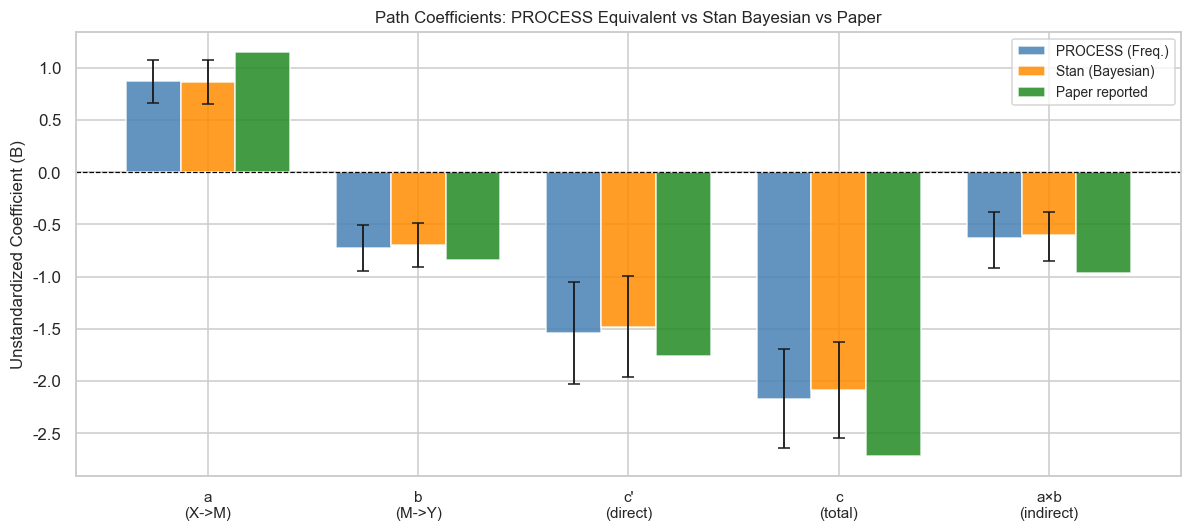

In [26]:
# ── 경로계수 비교 막대그래프 ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

labels    = ['a\n(X->M)', 'b\n(M->Y)', "c'\n(direct)", 'c\n(total)', 'a×b\n(indirect)']
freq_Bs   = [a_coef, b_coef, cp_coef, c_coef, ind_hat]
freq_los  = [a_ci[0], b_ci[0], cp_ci[0], c_ci[0], ci_lo]
freq_his  = [a_ci[1], b_ci[1], cp_ci[1], c_ci[1], ci_hi]
paper_Bs  = [1.15, -0.84, -1.76, -2.72, -0.97]
stan_pars = ['a', 'b', 'cp', 'total', 'indirect']

bayes_ms  = [bayes_ci(p)[0] for p in stan_pars]
bayes_los = [bayes_ci(p)[2] for p in stan_pars]
bayes_his = [bayes_ci(p)[3] for p in stan_pars]

x = np.arange(5); w = 0.26

ax.bar(x - w, freq_Bs,   w, label='PROCESS (Freq.)', color='steelblue',   alpha=0.85)
ax.bar(x,     bayes_ms,  w, label='Stan (Bayesian)', color='darkorange',  alpha=0.85)
ax.bar(x + w, paper_Bs,  w, label='Paper reported',  color='forestgreen', alpha=0.85)

# 오차막대
f_elo = [b - lo for b, lo in zip(freq_Bs, freq_los)]
f_ehi = [hi - b for b, hi in zip(freq_Bs, freq_his)]
b_elo = [m - lo for m, lo in zip(bayes_ms, bayes_los)]
b_ehi = [hi - m for m, hi in zip(bayes_ms, bayes_his)]

ax.errorbar(x - w, freq_Bs,  yerr=[f_elo, f_ehi], fmt='none', color='k', capsize=4, lw=1.2)
ax.errorbar(x,     bayes_ms, yerr=[b_elo, b_ehi], fmt='none', color='k', capsize=4, lw=1.2)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Unstandardized Coefficient (B)', fontsize=11)
ax.set_title('Path Coefficients: PROCESS Equivalent vs Stan Bayesian vs Paper', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

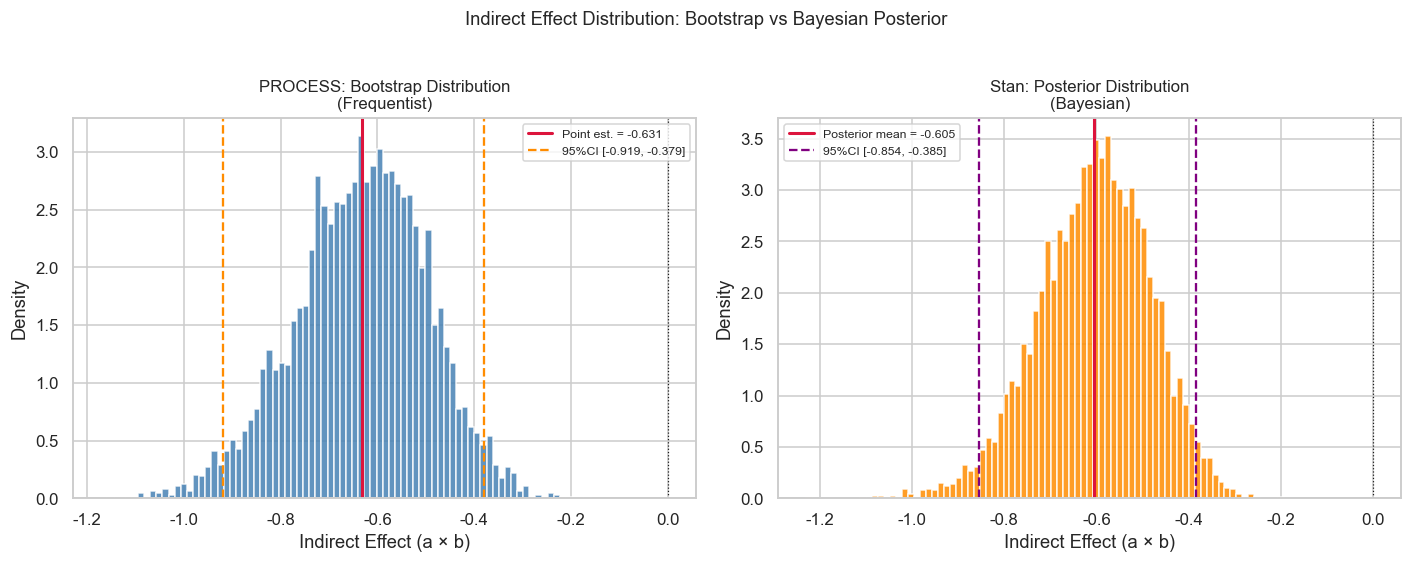

In [27]:
# ── 간접효과: Bootstrap vs 베이지언 사후분포 ────────────────────────────────
bayes_ind = post['indirect'].values
blo95, bhi95 = np.percentile(bayes_ind, [2.5, 97.5])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Bootstrap
axes[0].hist(ind_boot, bins=80, density=True,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(ind_hat, color='crimson',    lw=2.0,
                label=f'Point est. = {ind_hat:.3f}')
axes[0].axvline(ci_lo,  color='darkorange', lw=1.5, ls='--',
                label=f'95%CI [{ci_lo:.3f}, {ci_hi:.3f}]')
axes[0].axvline(ci_hi,  color='darkorange', lw=1.5, ls='--')
axes[0].axvline(0, color='k', lw=0.8, ls=':')
axes[0].set_title('PROCESS: Bootstrap Distribution\n(Frequentist)', fontsize=11)
axes[0].set_xlabel('Indirect Effect (a × b)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Right: Bayesian posterior
axes[1].hist(bayes_ind, bins=80, density=True,
             color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(bayes_ind.mean(), color='crimson', lw=2.0,
                label=f'Posterior mean = {bayes_ind.mean():.3f}')
axes[1].axvline(blo95, color='purple', lw=1.5, ls='--',
                label=f'95%CI [{blo95:.3f}, {bhi95:.3f}]')
axes[1].axvline(bhi95, color='purple', lw=1.5, ls='--')
axes[1].axvline(0, color='k', lw=0.8, ls=':')
axes[1].set_title('Stan: Posterior Distribution\n(Bayesian)', fontsize=11)
axes[1].set_xlabel('Indirect Effect (a × b)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

fig.suptitle('Indirect Effect Distribution: Bootstrap vs Bayesian Posterior', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

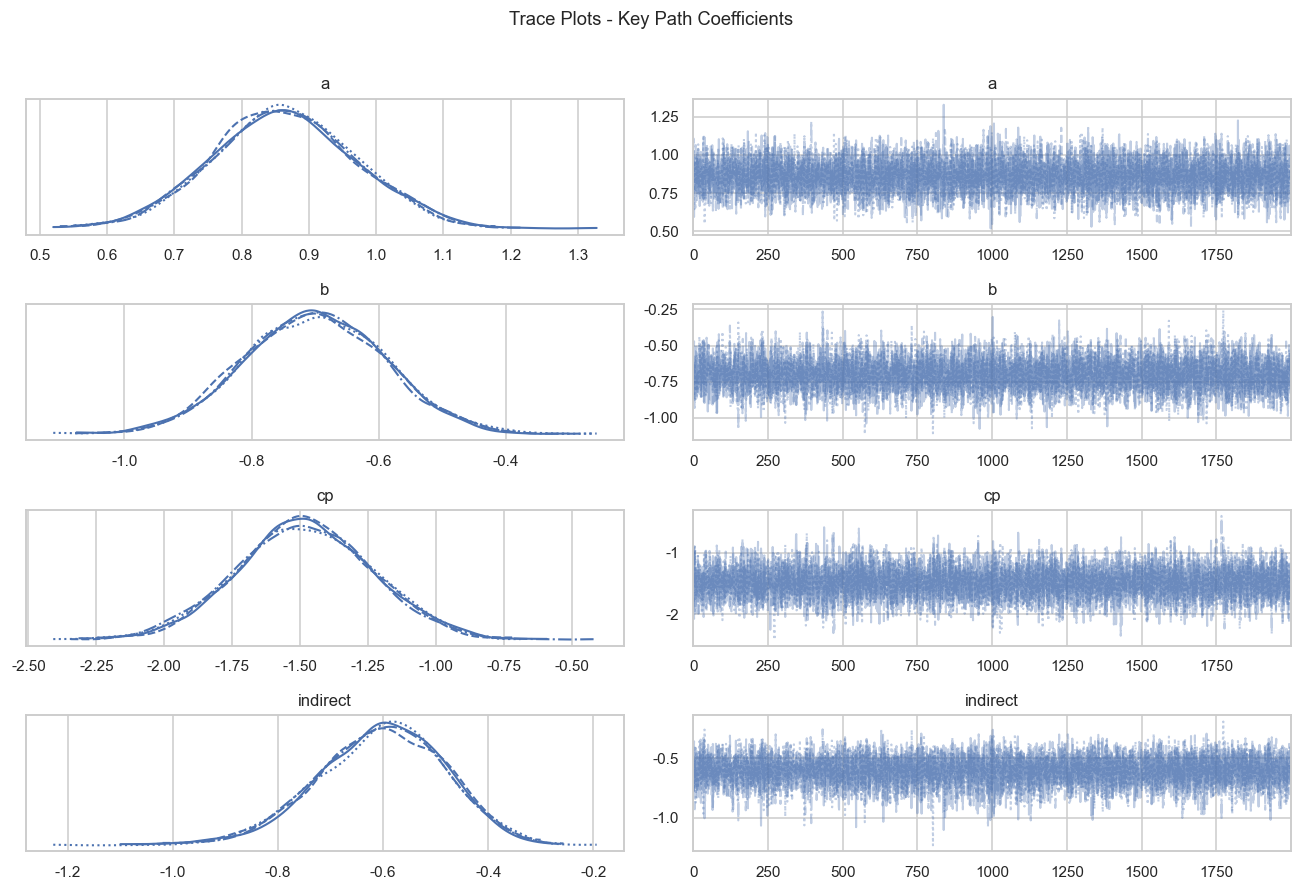

In [28]:
# ── Trace plot ────────────────────────────────────────────────────────────────
az.plot_trace(
    idata,
    var_names=['a', 'b', 'cp', 'indirect'],
    compact=True,
    figsize=(12, 8),
)
plt.suptitle('Trace Plots - Key Path Coefficients', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

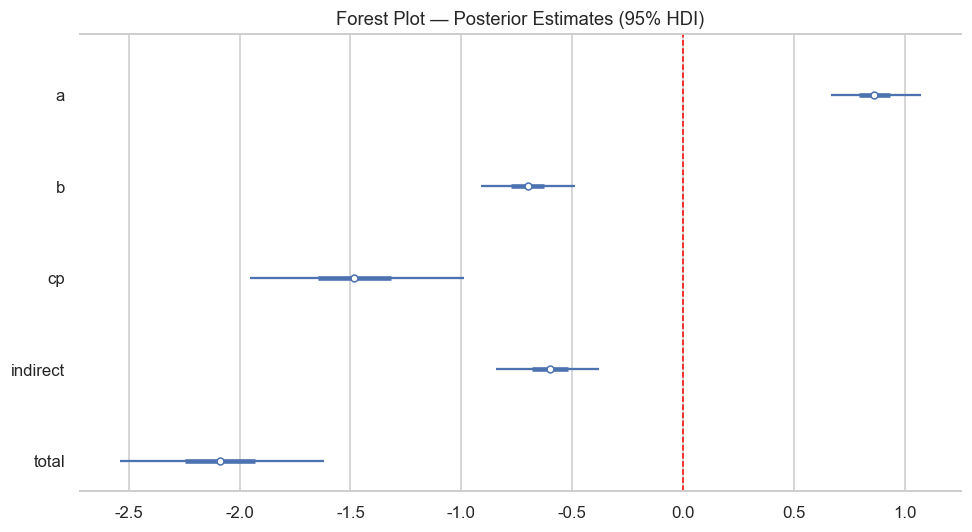

In [29]:
# ── Forest plot ───────────────────────────────────────────────────────────────
az.plot_forest(
    idata,
    var_names=['a', 'b', 'cp', 'indirect', 'total'],
    hdi_prob=0.95,
    combined=True,
    figsize=(9, 5),
)
plt.title('Forest Plot — Posterior Estimates (95% HDI)', fontsize=12)
plt.axvline(0, color='red', lw=1, ls='--')
plt.tight_layout()
plt.show()

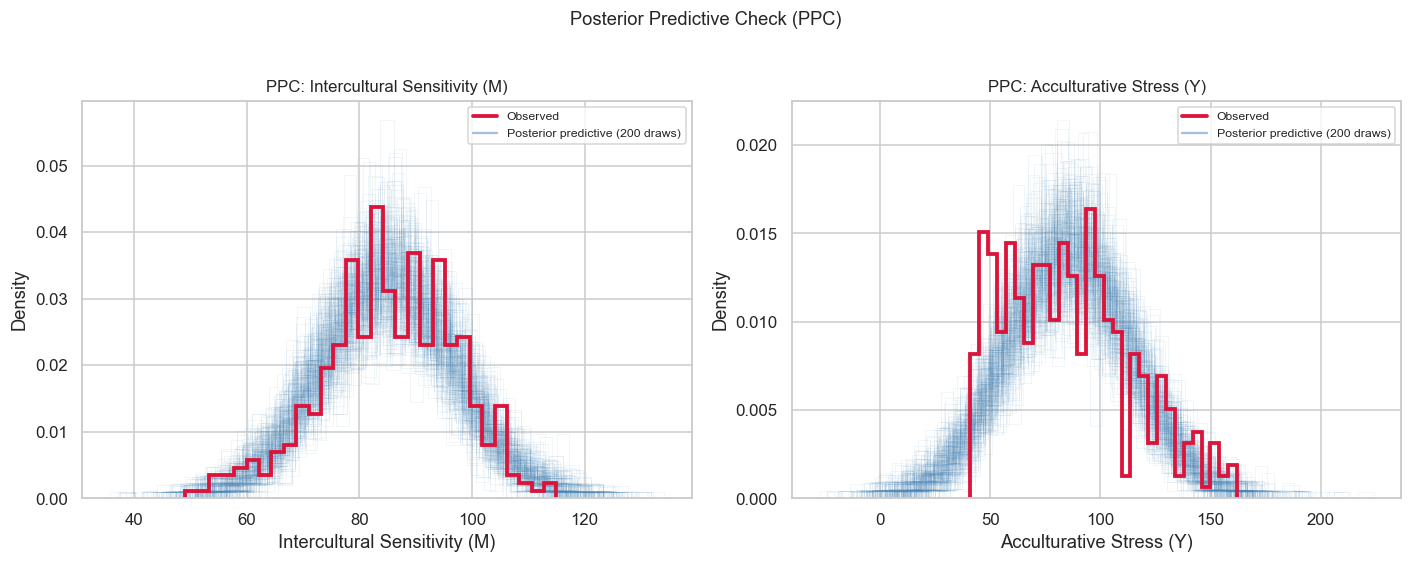

In [30]:
# ── 사후 예측 체크 (PPC) — 수동 구현 (ArviZ API 버전 호환) ───────────────────
# posterior_predictive 배열 추출
M_rep = idata.posterior_predictive['M_rep'].values   # (chains, draws, N)
Y_rep = idata.posterior_predictive['Y_rep'].values

M_rep_flat = M_rep.reshape(-1, N)   # (chains*draws, N)
Y_rep_flat = Y_rep.reshape(-1, N)

# 200개 샘플만 사용
rng_ppc = np.random.default_rng(0)
idx_ppc = rng_ppc.integers(0, M_rep_flat.shape[0], 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, rep_flat, obs, lbl in [
    (axes[0], M_rep_flat, M, 'Intercultural Sensitivity (M)'),
    (axes[1], Y_rep_flat, Y, 'Acculturative Stress (Y)'),
]:
    # 예측 분포 (얇은 선)
    for i in idx_ppc:
        ax.hist(rep_flat[i], bins=30, density=True,
                histtype='step', color='steelblue', alpha=0.08, lw=0.6)
    # 관측 분포 (굵은 선)
    ax.hist(obs, bins=30, density=True,
            histtype='step', color='crimson', lw=2.5, label='Observed')
    # 범례용 proxy
    from matplotlib.lines import Line2D
    proxy = Line2D([0], [0], color='steelblue', alpha=0.5, lw=1.5)
    ax.legend(handles=[Line2D([0],[0], color='crimson', lw=2.5),
                        proxy],
              labels=['Observed', 'Posterior predictive (200 draws)'],
              fontsize=8)
    ax.set_xlabel(lbl)
    ax.set_ylabel('Density')
    ax.set_title(f'PPC: {lbl}', fontsize=11)

fig.suptitle('Posterior Predictive Check (PPC)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 최종 요약 및 결론

In [31]:
# ── 최종 요약 테이블 ──────────────────────────────────────────────────────────
ind_prob_neg = (bayes_ind < 0).mean()

print('╔' + '═'*70 + '╗')
print('║  Final Results: Paper / PROCESS Equivalent / Stan Bayesian' + ' '*11 + '║')
print('╠' + '═'*70 + '╣')
print(f"║  {'Effect':<20} {'Paper':>7}  {'PROCESS B':>10}  {'Bayes mean':>10}  {'Match':>5}  ║")
print('╠' + '─'*70 + '╣')

for lbl, pv, fv, bp in [
    ('a  (X -> M)',        1.15, a_coef,  bayes_ci('a')[0]),
    ('b  (M -> Y)',       -0.84, b_coef,  bayes_ci('b')[0]),
    ("c' (direct X->Y)", -1.76, cp_coef, bayes_ci('cp')[0]),
    ('c  (total  X->Y)', -2.72, c_coef,  bayes_ci('total')[0]),
    ('Indirect (a x b)', -0.97, ind_hat, bayes_ci('indirect')[0]),
]:
    ok = '✓' if abs(fv - bp) < 0.40 else '△'
    print(f'║  {lbl:<20} {pv:>7.3f}  {fv:>10.4f}  {bp:>10.4f}  {ok:>5}  ║')

print('╠' + '─'*70 + '╣')
print(f'║  R²(M)           paper=0.26   PROCESS={r2_M:.4f}' + ' '*21 + '║')
print(f'║  R²(Y|X,M)       paper=0.34   PROCESS={r2_Y:.4f}' + ' '*21 + '║')
print('╠' + '═'*70 + '╣')
print('║  Indirect Effect 95% CI' + ' '*46 + '║')
print(f'║    Bootstrap (PROCESS): [{ci_lo:>8.4f},  {ci_hi:>8.4f}]' + ' '*21 + '║')
print(f'║    Stan Posterior:      [{blo95:>8.4f},  {bhi95:>8.4f}]' + ' '*21 + '║')
print('║    Paper reports:       [  -1.6400,    -0.3800]' + ' '*21 + '║')
print('╠' + '═'*70 + '╣')
print('║  Bayesian-only result:' + ' '*47 + '║')
print(f'║  P(indirect < 0 | data) = {ind_prob_neg:.4f} ({ind_prob_neg*100:.1f}%)' + ' '*27 + '║')
print('║  -> Bayesian allows direct probability statements about the' + ' '*10 + '║')
print('║     indirect effect, which frequentist CI cannot provide.' + ' '*11 + '║')
print('╠' + '═'*70 + '╣')
print('║  Conclusion: Indirect effect CI excludes 0.                       ║')
print('║  -> Mediation via Intercultural Sensitivity is significant.        ║')
print('║     Both frequentist and Bayesian analyses support this.           ║')
print('╚' + '═'*70 + '╝')

╔══════════════════════════════════════════════════════════════════════╗
║  Final Results: Paper / PROCESS Equivalent / Stan Bayesian           ║
╠══════════════════════════════════════════════════════════════════════╣
║  Effect                 Paper   PROCESS B  Bayes mean  Match  ║
╠──────────────────────────────────────────────────────────────────────╣
║  a  (X -> M)            1.150      0.8682      0.8631      ✓  ║
║  b  (M -> Y)           -0.840     -0.7268     -0.7005      ✓  ║
║  c' (direct X->Y)      -1.760     -1.5404     -1.4832      ✓  ║
║  c  (total  X->Y)      -2.720     -2.1714     -2.0879      ✓  ║
║  Indirect (a x b)      -0.970     -0.6310     -0.6047      ✓  ║
╠──────────────────────────────────────────────────────────────────────╣
║  R²(M)           paper=0.26   PROCESS=0.1710                     ║
║  R²(Y|X,M)       paper=0.34   PROCESS=0.3108                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Indirect Effect 95% CI   

In [32]:
# ── 빈도주의 vs 베이지언 방법론 비교표 ────────────────────────────────────────
comp = pd.DataFrame({
    'Item': [
        'Indirect effect estimation',
        'Uncertainty quantification',
        'Significance test',
        'Prior information',
        'Small-sample behavior',
        'Computation',
        'Result interpretation',
        'Probabilistic statement',
    ],
    'PROCESS Macro (Frequentist)': [
        'a×b point est. + bootstrap CI',
        '95% percentile CI',
        'CI excludes 0?',
        'Not possible',
        'Depends on bootstrap size',
        'OLS + 5,000 bootstrap iterations',
        '"CI covers true value in 95% of repeated experiments"',
        'Not possible',
    ],
    'Stan Bayesian': [
        'Full posterior p(a×b | data)',
        '95% HDI (direct probability)',
        'HDI excludes 0 / ROPE analysis',
        'Informative priors allowed',
        'MCMC effective sample size',
        'HMC/NUTS MCMC',
        '"95% prob. that param is in this interval"',
        'P(a×b < 0 | data) = X%',
    ]
}).set_index('Item')

print('Method Comparison: PROCESS Macro vs Stan Bayesian')
print('=' * 100)
for idx, row in comp.iterrows():
    print(f'\n  {idx}')
    print(f'    Freq : {row["PROCESS Macro (Frequentist)"]}')
    print(f'    Bayes: {row["Stan Bayesian"]}')
print('=' * 100)

Method Comparison: PROCESS Macro vs Stan Bayesian

  Indirect effect estimation
    Freq : a×b point est. + bootstrap CI
    Bayes: Full posterior p(a×b | data)

  Uncertainty quantification
    Freq : 95% percentile CI
    Bayes: 95% HDI (direct probability)

  Significance test
    Freq : CI excludes 0?
    Bayes: HDI excludes 0 / ROPE analysis

  Prior information
    Freq : Not possible
    Bayes: Informative priors allowed

  Small-sample behavior
    Freq : Depends on bootstrap size
    Bayes: MCMC effective sample size

  Computation
    Freq : OLS + 5,000 bootstrap iterations
    Bayes: HMC/NUTS MCMC

  Result interpretation
    Freq : "CI covers true value in 95% of repeated experiments"
    Bayes: "95% prob. that param is in this interval"

  Probabilistic statement
    Freq : Not possible
    Bayes: P(a×b < 0 | data) = X%
